# Thesis Figure 6 Ã¢â‚¬â€ Region Growing

Illustrates how CIAO builds up an explanation region-by-region.

Three images (saved individually, no axes/titles):
1. **Region 0 only** Ã¢â‚¬â€ the first grown region, one colour.
2. **Regions 0 + 1** Ã¢â‚¬â€ first two regions, two distinct colours.
3. **All three regions** Ã¢â‚¬â€ all three distinct colours.

Source: MLflow run `ucb-3regions-42-length-20`, child `imagenets_0032.jpg`.

Edit only the **Configuration** cell.

In [1]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Configuration Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
IMAGE_PATH = r"REPO_ROOT/images\images\imagenets_0032.jpg"

TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
MLFLOW_USER = "YOUR_MLFLOW_USERNAME"
MLFLOW_PASSWORD = "YOUR_MLFLOW_PASSWORD"
EXPERIMENT_NAME = "ucb-multiple-regions"
PARENT_RUN_NAME = "ucb-3regions-42-length-20"
CHILD_RUN_NAME = "imagenets_0032.jpg"

SEG_OVERRIDES = [
    "segmentation=hexagonal",
]

# Colours for region 0, 1, 2 overlays (matplotlib-compatible)
REGION_COLORS = ["#e63946", "#2a9d8f", "#e9c46a"]  # red, teal, amber
REGION_ALPHA = 0.55  # opacity of the coloured overlay

OUTPUT_DIR = "output"

In [2]:
import json
import os
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from matplotlib.colors import to_rgba


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.visualization.visualization import _to_hwc


os.environ["MLFLOW_TRACKING_USERNAME"] = MLFLOW_USER
os.environ["MLFLOW_TRACKING_PASSWORD"] = MLFLOW_PASSWORD
mlflow.set_tracking_uri(TRACKING_URI)

OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  repo: {REPO_ROOT}")

device: cpu  |  repo: REPO_ROOT/n

In [3]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Fetch segment lists from MLflow Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
client = mlflow.tracking.MlflowClient()

exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f"Experiment {EXPERIMENT_NAME!r} not found."

parent_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.`mlflow.runName` = '{PARENT_RUN_NAME}'",
    output_format="pandas",
)
assert len(parent_runs) == 1, f"Expected 1 parent run, got {len(parent_runs)}."
parent_run_id = parent_runs.iloc[0]["run_id"]
print(f"Parent run: {parent_run_id}")

child_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=(
        f"tags.`mlflow.parentRunId` = '{parent_run_id}' "
        f"AND tags.`mlflow.runName` = '{CHILD_RUN_NAME}'"
    ),
    output_format="pandas",
)
assert len(child_runs) == 1, f"Expected 1 child run, got {len(child_runs)}."
child_run_id = child_runs.iloc[0]["run_id"]
print(f"Child run : {child_run_id}")

region_segments: list[list[int]] = []
with tempfile.TemporaryDirectory() as tmp:
    for i in range(3):
        path = client.download_artifacts(child_run_id, f"region_{i}/segments.json", tmp)
        with open(path) as f:
            data = json.load(f)
        region_segments.append(data["segments"])
        print(f"region_{i}: {len(data['segments'])} segments")

Parent run: 6106f876fc1841d38e6881b6763f3b4b
Child run : 292f8d7b5a1a4c9bbe367ac86ade9916


region_0: 20 segments


region_1: 20 segments


region_2: 20 segments


In [4]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Load image and segmentation Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="base", overrides=SEG_OVERRIDES + ["replacement=imagenet_mean"]
    )

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)
input_batch = img_tensor.unsqueeze(0)

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

img_np = _to_hwc(input_batch)  # [H, W, 3] float32 in [0, 1]
segs = image_graph.segments.cpu().numpy()  # [H, W] int32

print(f"Image shape : {img_np.shape}")
print(f"Segments    : {image_graph.num_segments} unique IDs")

Image shape : (224, 224, 3)
Segments    : 1273 unique IDs


In [5]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Build per-region binary masks Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
region_masks = []
for seg_ids in region_segments:
    mask = np.zeros(segs.shape, dtype=np.float32)
    for sid in seg_ids:
        mask[segs == sid] = 1.0
    region_masks.append(mask)
    print(f"pixels covered: {int(mask.sum())} / {mask.size}")

pixels covered: 824 / 50176
pixels covered: 823 / 50176
pixels covered: 833 / 50176


In [6]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Helper Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
def save(fig: plt.Figure, stem: str) -> None:
    fig.savefig(OUT / f"{stem}.png", dpi=150, bbox_inches="tight")
    fig.savefig(OUT / f"{stem}.pdf", dpi=150, bbox_inches="tight")
    print(f"Saved Ã¢â€ â€™ {OUT / stem}.png")


def overlay_regions(
    base: np.ndarray,
    masks: list[np.ndarray],
    colors: list[str],
    alpha: float,
) -> np.ndarray:
    """Blend coloured overlays onto base image. Returns HWC float32 in [0,1]."""
    result = base.copy()
    for mask, color in zip(masks, colors, strict=False):
        rgb = np.array(to_rgba(color)[:3], dtype=np.float32)
        where = mask > 0
        result[where] = (1 - alpha) * result[where] + alpha * rgb
    return result


print("Helpers ready.")

Helpers ready.


Saved Ã¢â€ â€™ output\region_growing_step1.png


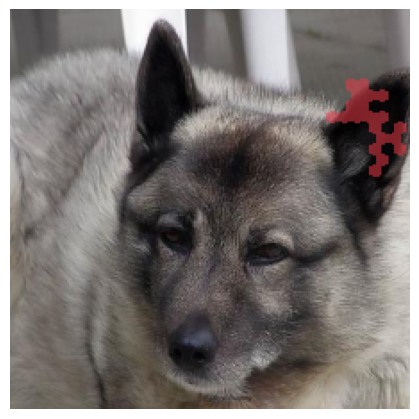

In [7]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure 1: region 0 only Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
composite = overlay_regions(img_np, region_masks[:1], REGION_COLORS[:1], REGION_ALPHA)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(composite)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "region_growing_step1")
plt.show()

Saved Ã¢â€ â€™ output\region_growing_step2.png


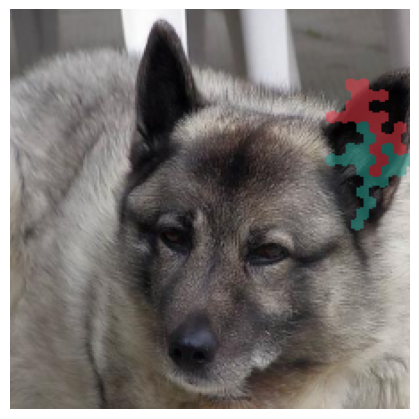

In [8]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure 2: regions 0 + 1 Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
composite = overlay_regions(img_np, region_masks[:2], REGION_COLORS[:2], REGION_ALPHA)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(composite)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "region_growing_step2")
plt.show()

Saved Ã¢â€ â€™ output\region_growing_step3.png


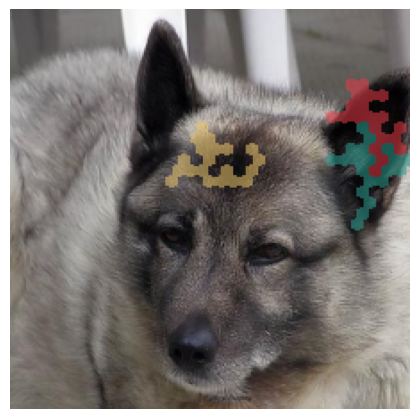

In [9]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure 3: all three regions Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
composite = overlay_regions(img_np, region_masks[:3], REGION_COLORS[:3], REGION_ALPHA)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(composite)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "region_growing_step3")
plt.show()